### [Spot Exponential Stock Trends](https://medium.com/coding-nexus/easily-spot-exponential-stock-trends-with-python-e5263951f13f)

In [1]:
!pip install -q yfinance statsmodels matplotlib

In [2]:
import sys
from IPython.display import display

IN_COLAB = 'google.colab' in sys.modules

import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:0.4f}'.format)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 200

%autosave 10

Autosaving every 10 seconds


In [3]:
# Download 10 years of daily closing prices for XLY
close = (
    yf.download("XLY", period="10y", interval="1d", auto_adjust=False, progress=False)
    .Close.dropna()
)
dates = close.index

display(close.head(10))

Ticker,XLY
Date,
2016-03-21,39.0650
2016-03-22,39.0000
2016-03-23,38.7250
2016-03-24,38.7750
2016-03-28,38.9500
2016-03-29,39.3450
2016-03-30,39.5950
2016-03-31,39.5500
2016-04-01,39.7150


In [4]:
def log_linear_regression(X, Y):
    """Fit log-linear model to (X, Y) and return model and smoothed predictions."""
    X_const = sm.add_constant(X)  # intercept
    model = sm.OLS(np.log(Y), X_const).fit()
    a, b = model.params

    # Smooth predictions for plotting
    X_smooth = np.linspace(X.min(), X.max(), 100)
    Y_hat = np.exp(a + b * X_smooth)
    return model, X_smooth, Y_hat

In [5]:
# time index
X = np.arange(len(close))
Y = close.values
model, X_smooth, Y_hat = log_linear_regression(X, Y)

# view R², coefficients, p-values
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                 1.850e+04
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:32:59   Log-Likelihood:                 1916.4
No. Observations:                2515   AIC:                            -3829.
Df Residuals:                    2513   BIC:                            -3817.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7140      0.005    824.537      0.000       3.705       3.723
x1             0.0004    3.1e-06    136.029      0.000       0.000       0.000
==============================================================================
Omnibus:                      119.242   Durbin-Watson:                   0.015
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              137.472
Skew:                           0.532   Prob(JB):                     1.41e-30
Kurtosis:                       3.423   Cond. No.                     2.90e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.9e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

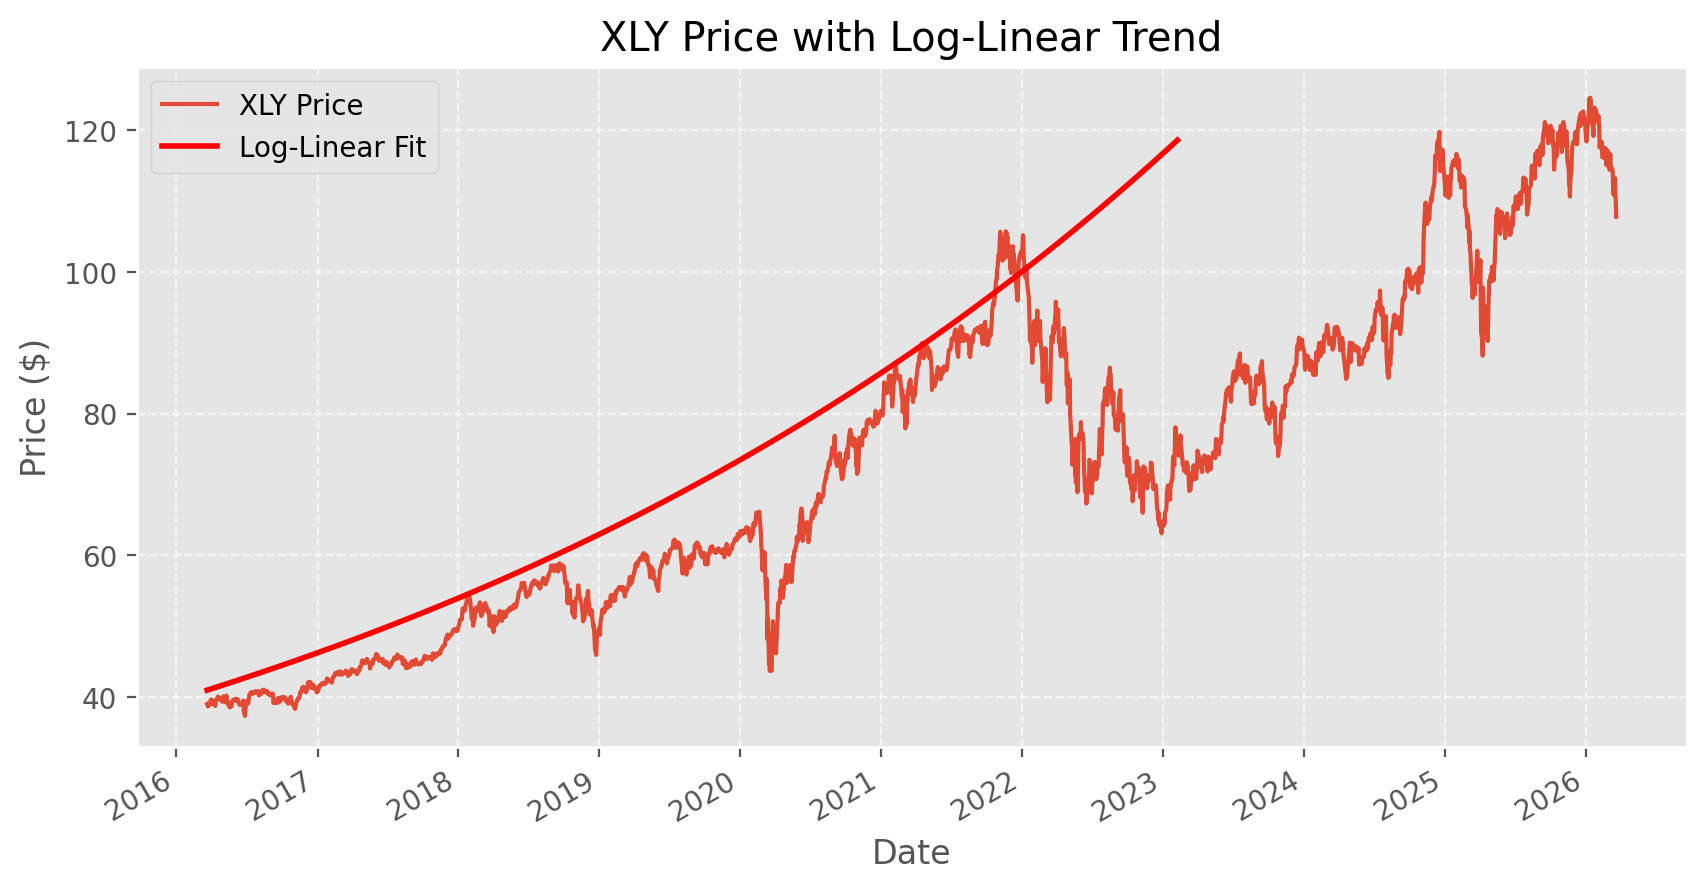

In [6]:
# Align smoothed X to dates safely
smooth_dates = pd.to_datetime(dates.min()) + pd.to_timedelta(X_smooth, unit="D")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dates, Y, label="XLY Price", linewidth=1.5)
ax.plot(smooth_dates, Y_hat, "r", label="Log-Linear Fit", linewidth=2)
ax.set_title("XLY Price with Log-Linear Trend")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
fig.autofmt_xdate()
plt.show()

In [7]:
tickers = ['XLY', 'XLE', 'XLK']
slopes = {}

for ticker in tickers:
    close = (
        yf.download(ticker, period="10y", interval="1d", auto_adjust=False, progress=False)
        .Close.dropna()
    )
    X = np.arange(len(close))
    Y = close.values
    model, _, _ = log_linear_regression(X, Y)
    slopes[ticker] = model.params[1]  # growth rate b

# Rank by slope descending
for t, b in sorted(slopes.items(), key=lambda x: x[1], reverse=True):
    annualised = (np.exp(b) ** 252 - 1) * 100  # approx annual %
    print(f"{t}: daily b={b:.5f}, annualised growth≈{annualised:.1f}%")

XLK: daily b=0.00075, annualised growth≈20.8%
XLY: daily b=0.00042, annualised growth≈11.2%
XLE: daily b=0.00016, annualised growth≈4.2%


In [8]:
window = 252
rolling_b = [
    sm.OLS(np.log(Y[i:i+window]), sm.add_constant(np.arange(window))).fit().params[1]
    for i in range(len(Y)-window)
]

display(rolling_b[:10])

[np.float64(0.0008092011929904257),
 np.float64(0.0008136634634471167),
 np.float64(0.0008185974131373625),
 np.float64(0.0008225955830928002),
 np.float64(0.0008267810510395122),
 np.float64(0.0008305832131508367),
 np.float64(0.000836385099876025),
 np.float64(0.000842763058872307),
 np.float64(0.0008489888254620697),
 np.float64(0.0008556232863724586)]